Shape: 4269 rows x 13 cols
Missing values:
Series([], dtype: int64)

Summary stats:
           loan_id   no_of_dependents   income_annum   loan_amount  \
count  4269.000000        4269.000000   4.269000e+03  4.269000e+03   
mean   2135.000000           2.498712   5.059124e+06  1.513345e+07   
std    1232.498479           1.695910   2.806840e+06  9.043363e+06   
min       1.000000           0.000000   2.000000e+05  3.000000e+05   
25%    1068.000000           1.000000   2.700000e+06  7.700000e+06   
50%    2135.000000           3.000000   5.100000e+06  1.450000e+07   
75%    3202.000000           4.000000   7.500000e+06  2.150000e+07   
max    4269.000000           5.000000   9.900000e+06  3.950000e+07   

         loan_term   cibil_score   residential_assets_value  \
count  4269.000000   4269.000000               4.269000e+03   
mean     10.900445    599.936051               7.472617e+06   
std       5.709187    172.430401               6.503637e+06   
min       2.000000    300.000000 

C:\Users\SSN\AppData\Local\Temp\ipykernel_22928\768255530.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[6].boxplot([df[c].dropna() for c in num_cols], labels=num_cols); ax[6].set_title("Outlier Overview")
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


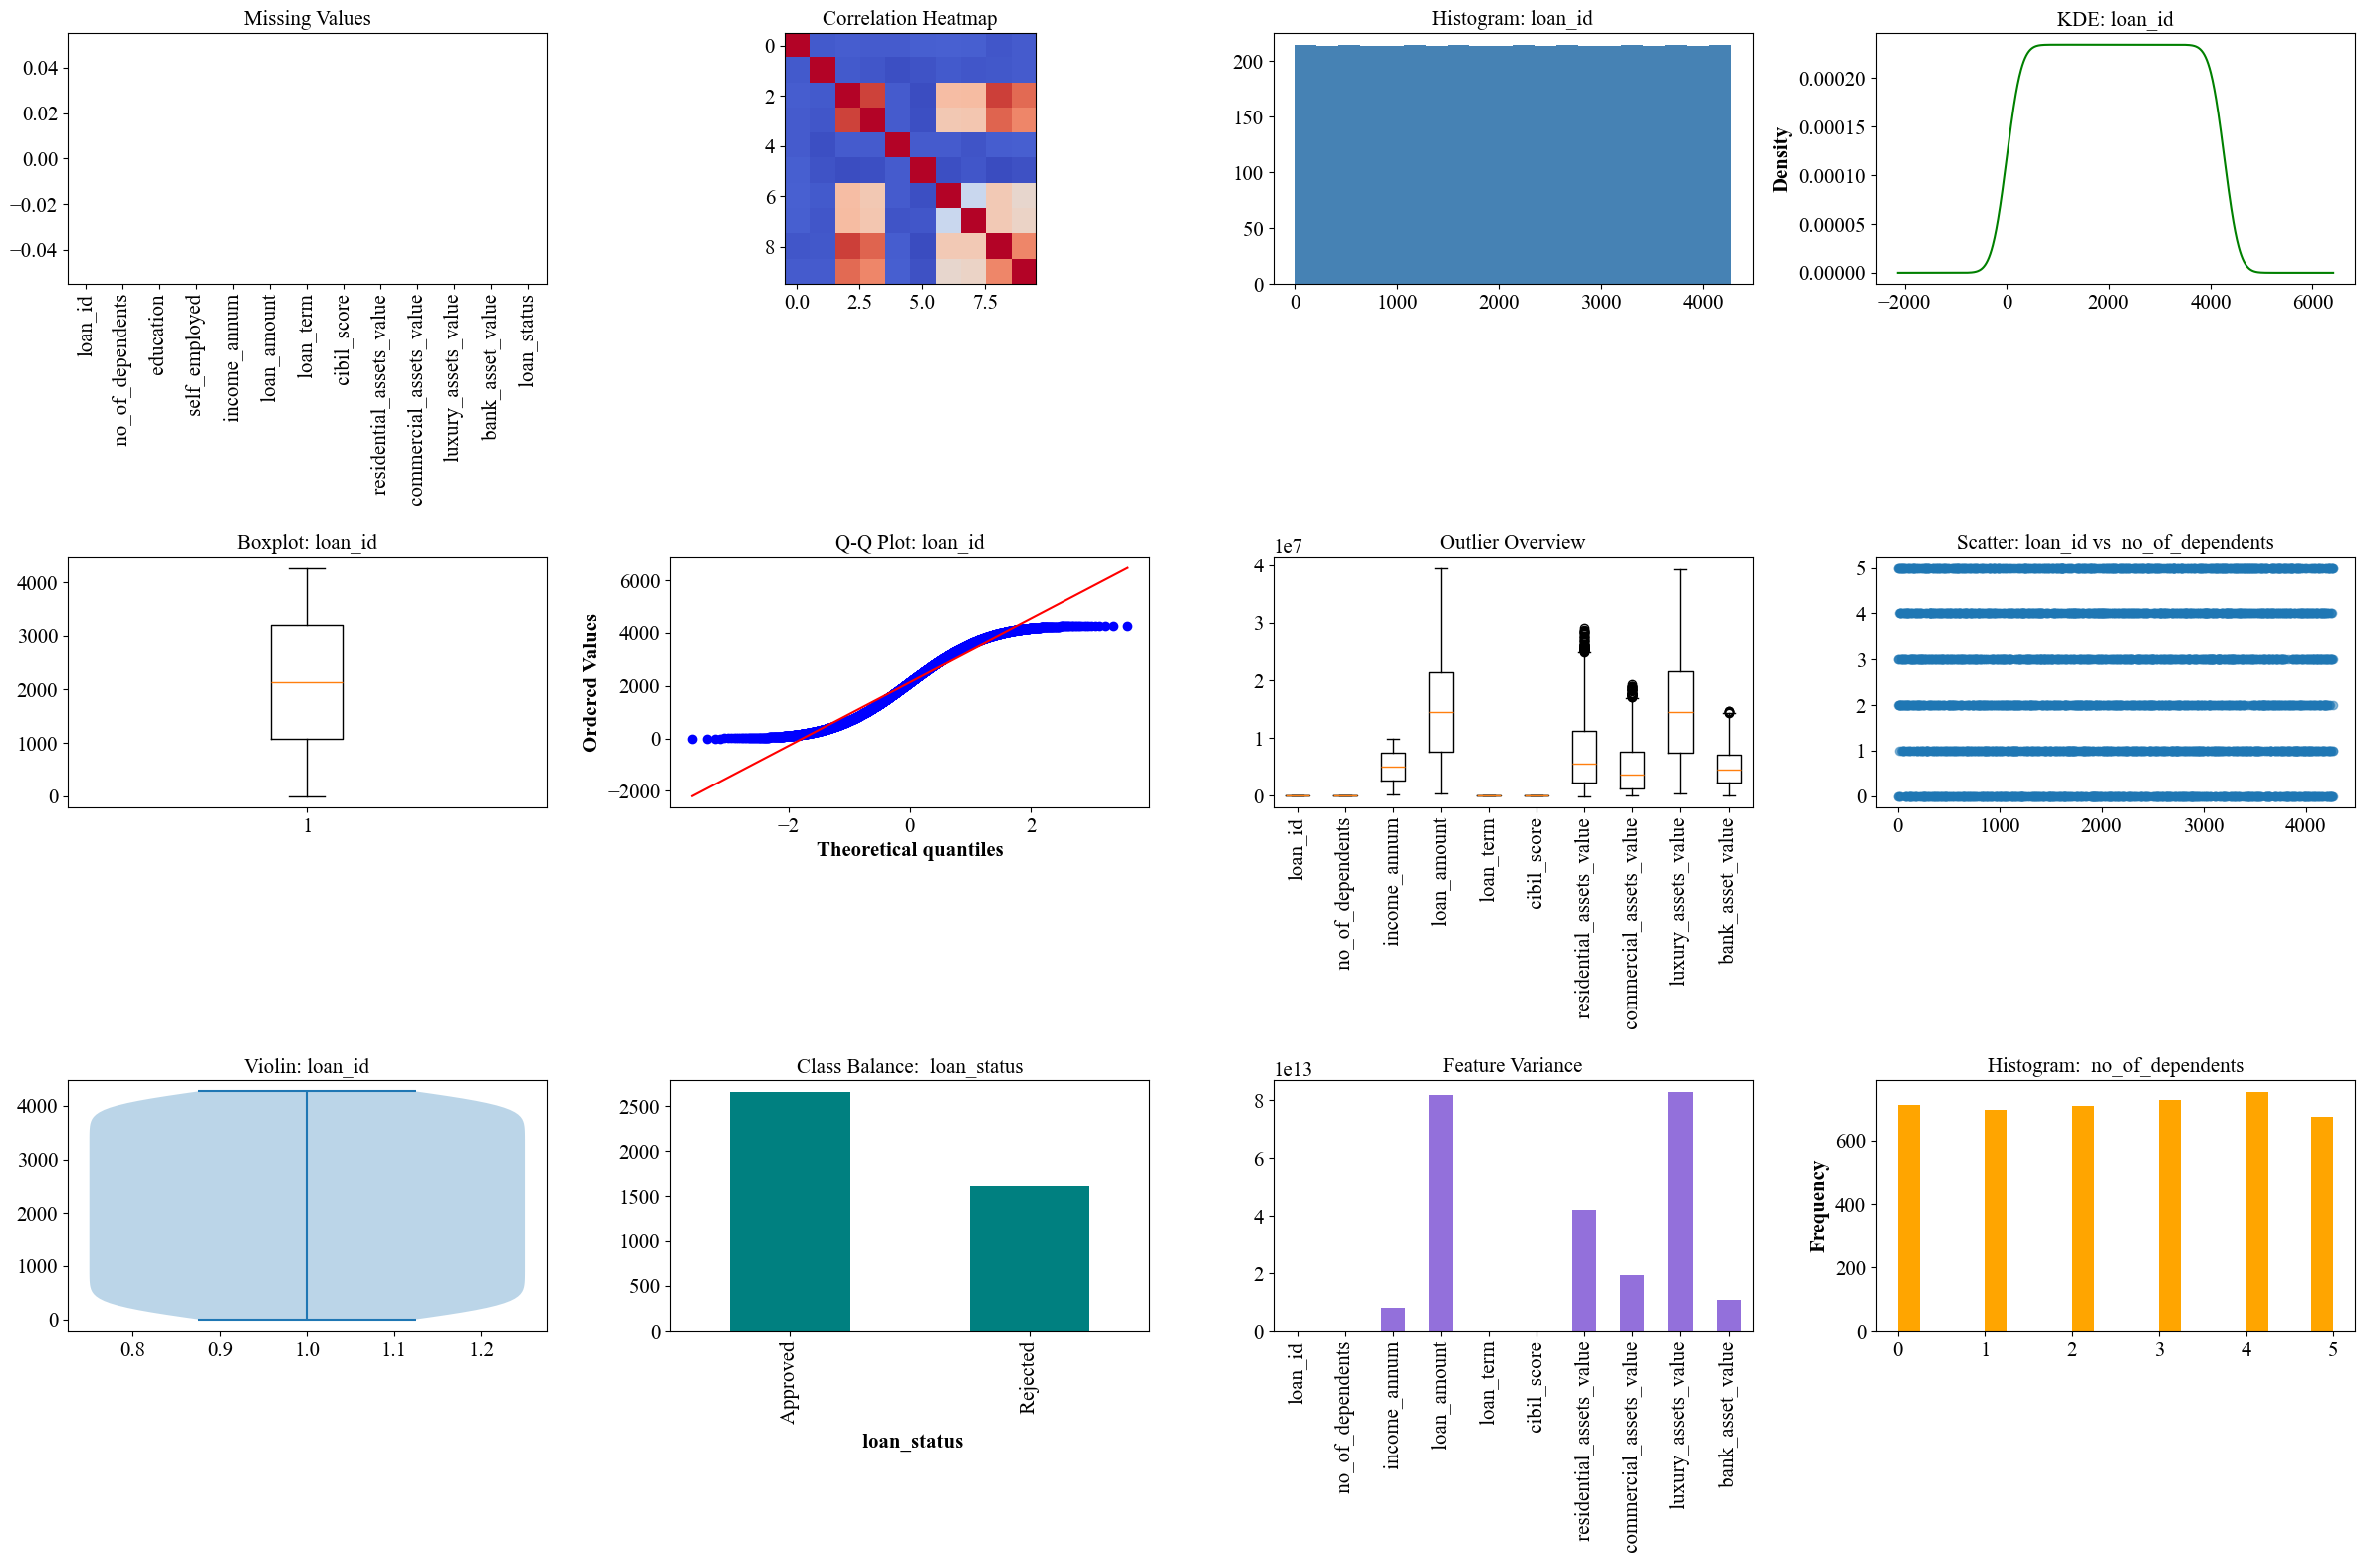

Saved: C:\Users\SSN\Desktop\eda.eps


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

# ---------- Global plot style ----------
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["font.size"] = 15
mpl.rcParams["legend.fontsize"] = 15
mpl.rcParams["axes.labelsize"] = 15
mpl.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 15


def describe_dataset(df, target=None):
    """Prints a short text summary of the dataset before plotting."""
    print(f"Shape: {df.shape[0]} rows x {df.shape[1]} cols")
    print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"\nSummary stats:\n{df.describe()}")
    if target:
        print(f"\nTarget '{target}' distribution:\n{df[target].value_counts()}")


def eda_summary_figure(df, target=None, output_path="eda_summary"):
    """One reusable function: 12-subplot EDA figure, saved as .eps @600 DPI."""
    describe_dataset(df, target)

    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    c1, c2 = num_cols[0], num_cols[1]  # first two numeric columns used throughout

    fig, ax = plt.subplots(3, 4, figsize=(24, 16))
    ax = ax.flatten()

    df.isnull().sum().plot(kind="bar", ax=ax[0], color="salmon", title="Missing Values")
    ax[1].imshow(df[num_cols].corr(), cmap="coolwarm"); ax[1].set_title("Correlation Heatmap")
    ax[2].hist(df[c1], bins=20, color="steelblue"); ax[2].set_title(f"Histogram: {c1}")
    df[c1].plot(kind="kde", ax=ax[3], color="green", title=f"KDE: {c1}")
    ax[4].boxplot(df[c1].dropna()); ax[4].set_title(f"Boxplot: {c1}")
    stats.probplot(df[c1].dropna(), dist="norm", plot=ax[5]); ax[5].set_title(f"Q-Q Plot: {c1}")
    ax[6].boxplot([df[c].dropna() for c in num_cols], labels=num_cols); ax[6].set_title("Outlier Overview")
    ax[6].tick_params(axis="x", rotation=90)
    ax[7].scatter(df[c1], df[c2], alpha=0.5); ax[7].set_title(f"Scatter: {c1} vs {c2}")
    ax[8].violinplot(df[c1].dropna()); ax[8].set_title(f"Violin: {c1}")
    if target:
        df[target].value_counts().plot(kind="bar", ax=ax[9], color="teal", title=f"Class Balance: {target}")
    df[num_cols].var().plot(kind="bar", ax=ax[10], color="mediumpurple", title="Feature Variance")
    ax[10].tick_params(axis="x", rotation=90)
    df[c2].plot(kind="hist", ax=ax[11], bins=20, color="orange", title=f"Histogram: {c2}")

    plt.tight_layout()
    fig.savefig(f"{output_path}.eps", format="eps", dpi=600)
    plt.show()
    print(f"Saved: {output_path}.eps")


if __name__ == "__main__":
    DATASET_PATH = r"C:\Users\SSN\Downloads\archive(1)\loan_approval_dataset.csv"
    TARGET_COLUMN =" loan_status"

    df = pd.read_csv(DATASET_PATH)
    eda_summary_figure(df, target=TARGET_COLUMN, output_path=r"C:\Users\SSN\Desktop\eda")

Documents: 5728
Avg char length: 1556.8, Avg word count: 326.8
Missing text entries: 0

Target 'spam' distribution:
spam
0    4360
1    1368
Name: count, dtype: int64


C:\Users\SSN\AppData\Local\Temp\ipykernel_22928\1329333981.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[3].boxplot(groups, labels=sorted(df[target].dropna().unique()))
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: eda_summary_nlp.eps


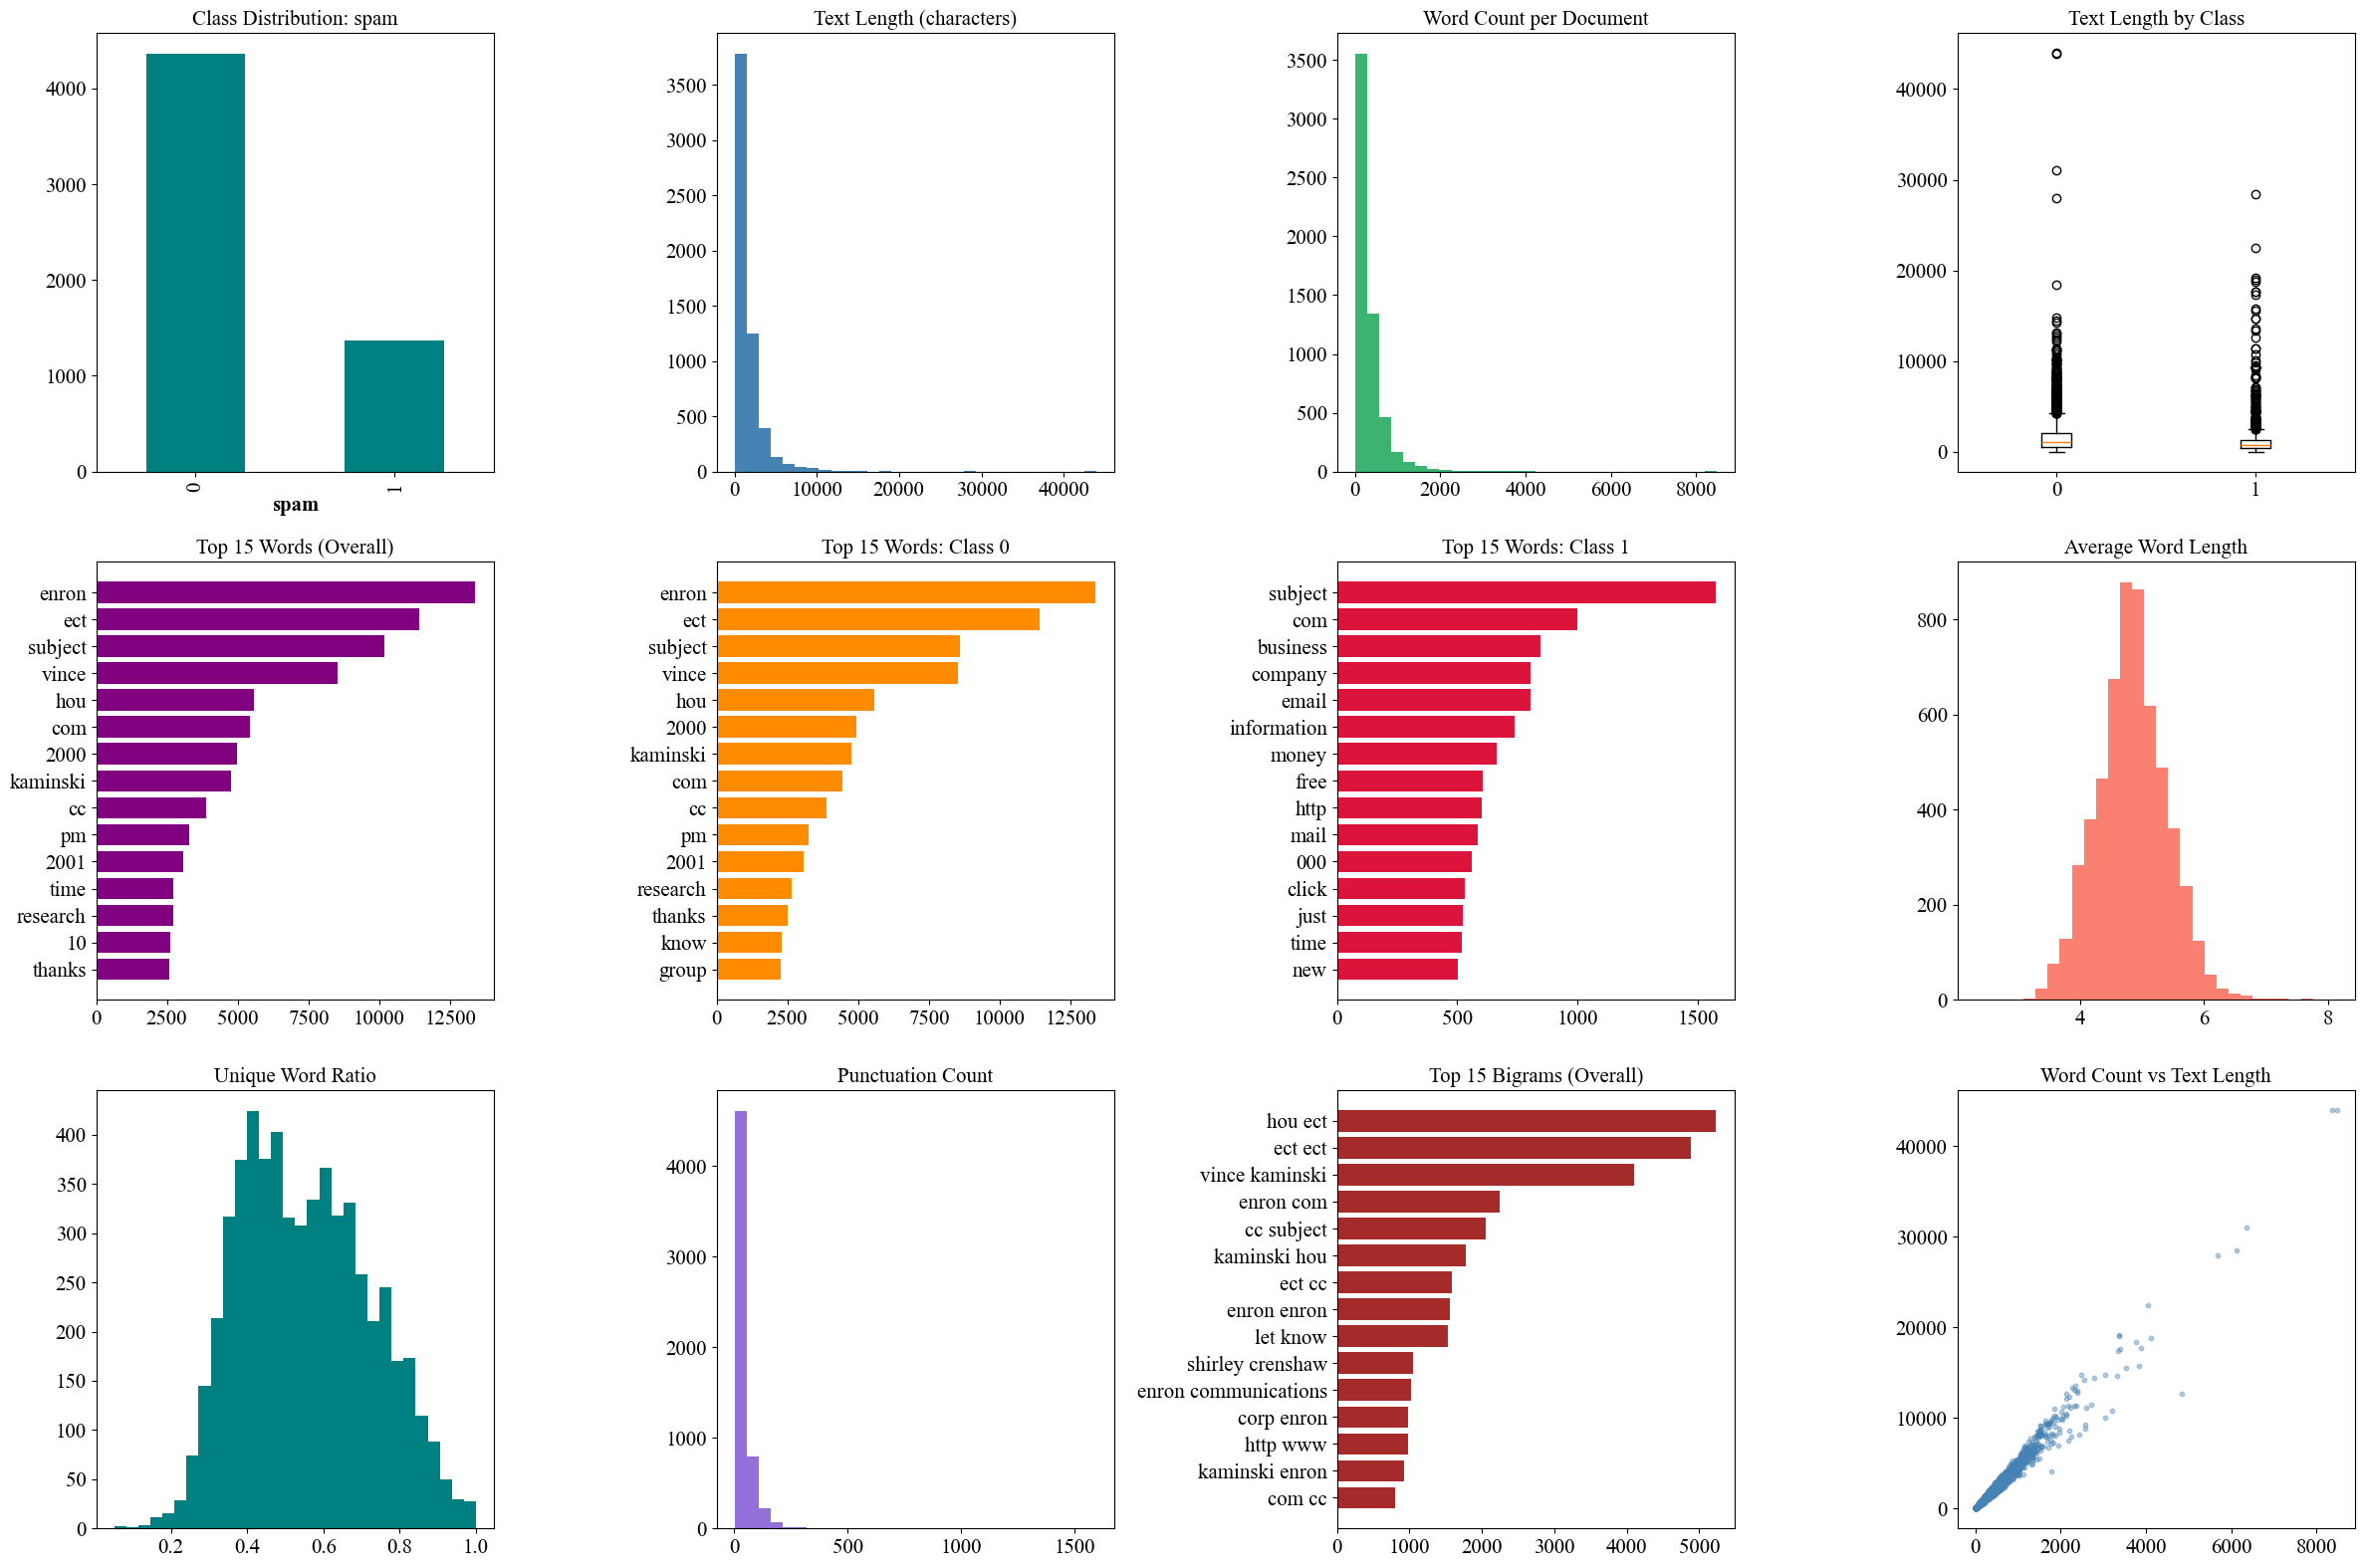

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.feature_extraction.text import CountVectorizer

# ---------- Global plot style ----------
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["font.size"] = 15
mpl.rcParams["legend.fontsize"] = 15
mpl.rcParams["axes.labelsize"] = 15
mpl.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 15


def describe_text_dataset(df, text_col, target=None):
    """Prints a short text summary of the NLP dataset before plotting."""
    lengths = df[text_col].str.len()
    words = df[text_col].str.split().str.len()
    print(f"Documents: {len(df)}")
    print(f"Avg char length: {lengths.mean():.1f}, Avg word count: {words.mean():.1f}")
    print(f"Missing text entries: {df[text_col].isnull().sum()}")
    if target:
        print(f"\nTarget '{target}' distribution:\n{df[target].value_counts()}")


def _top_words(texts, n=15):
    """Returns top-n words by frequency using CountVectorizer (built-in English
    stopword list, no external downloads needed)."""
    vec = CountVectorizer(stop_words="english", max_features=5000)
    X = vec.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).flatten()
    vocab = np.array(vec.get_feature_names_out())
    top_idx = freqs.argsort()[::-1][:n]
    return vocab[top_idx], freqs[top_idx]


def _top_bigrams(texts, n=15):
    vec = CountVectorizer(stop_words="english", ngram_range=(2, 2), max_features=5000)
    X = vec.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).flatten()
    vocab = np.array(vec.get_feature_names_out())
    top_idx = freqs.argsort()[::-1][:n]
    return vocab[top_idx], freqs[top_idx]


def eda_summary_figure_nlp(df, text_col, target=None, output_path="eda_summary_nlp"):
    """One reusable function: 12-subplot NLP EDA figure, saved as .eps @600 DPI."""
    describe_text_dataset(df, text_col, target)

    texts = df[text_col].dropna().astype(str)
    lengths = texts.str.len()
    word_counts = texts.str.split().str.len()
    avg_word_len = lengths / word_counts.replace(0, np.nan)
    punct_counts = texts.str.count(r"[!?.,;:]")
    unique_word_ratio = texts.apply(lambda t: len(set(t.lower().split())) / max(len(t.split()), 1))

    fig, ax = plt.subplots(3, 4, figsize=(24, 16))
    ax = ax.flatten()

    # 1. Class distribution
    if target:
        df[target].value_counts().plot(kind="bar", ax=ax[0], color="teal", title=f"Class Distribution: {target}")
    else:
        ax[0].text(0.5, 0.5, "No target column", ha="center", va="center"); ax[0].set_title("Class Distribution")

    # 2. Character length histogram
    ax[1].hist(lengths, bins=30, color="steelblue")
    ax[1].set_title("Text Length (characters)")

    # 3. Word count histogram
    ax[2].hist(word_counts, bins=30, color="mediumseagreen")
    ax[2].set_title("Word Count per Document")

    # 4. Text length by class (boxplot)
    if target:
        groups = [lengths[df[target] == c] for c in sorted(df[target].dropna().unique())]
        ax[3].boxplot(groups, labels=sorted(df[target].dropna().unique()))
        ax[3].set_title("Text Length by Class")
    else:
        ax[3].boxplot(lengths); ax[3].set_title("Text Length (overall)")

    # 5. Top 15 words overall
    words, freqs = _top_words(texts)
    ax[4].barh(words[::-1], freqs[::-1], color="purple")
    ax[4].set_title("Top 15 Words (Overall)")

    # 6-7. Top 15 words per class (if binary/few classes)
    if target and df[target].nunique() <= 2:
        classes = sorted(df[target].dropna().unique())
        for i, c in enumerate(classes[:2]):
            class_texts = texts[df[target] == c]
            w, f = _top_words(class_texts)
            ax[5 + i].barh(w[::-1], f[::-1], color="darkorange" if i == 0 else "crimson")
            ax[5 + i].set_title(f"Top 15 Words: Class {c}")
    else:
        ax[5].text(0.5, 0.5, "No/too many classes", ha="center", va="center"); ax[5].set_title("Top Words: Class A")
        ax[6].text(0.5, 0.5, "No/too many classes", ha="center", va="center"); ax[6].set_title("Top Words: Class B")

    # 8. Average word length histogram
    ax[7].hist(avg_word_len.dropna(), bins=30, color="salmon")
    ax[7].set_title("Average Word Length")

    # 9. Unique word ratio histogram (vocabulary richness)
    ax[8].hist(unique_word_ratio, bins=30, color="teal")
    ax[8].set_title("Unique Word Ratio")

    # 10. Punctuation count histogram
    ax[9].hist(punct_counts, bins=30, color="mediumpurple")
    ax[9].set_title("Punctuation Count")

    # 11. Top 15 bigrams overall
    bigrams, bfreqs = _top_bigrams(texts)
    ax[10].barh(bigrams[::-1], bfreqs[::-1], color="brown")
    ax[10].set_title("Top 15 Bigrams (Overall)")

    # 12. Word count vs text length scatter
    ax[11].scatter(word_counts, lengths, alpha=0.4, s=10, color="steelblue")
    ax[11].set_title("Word Count vs Text Length")

    plt.tight_layout()
    fig.savefig(f"{output_path}.eps", format="eps", dpi=600)
    print(f"Saved: {output_path}.eps")


if __name__ == "__main__":
    DATASET_PATH = r"C:\Users\SSN\Downloads\archive(4)\emails.csv"
    TEXT_COLUMN = "text"
    TARGET_COLUMN = "spam"  # or None

    df = pd.read_csv(DATASET_PATH)
    eda_summary_figure_nlp(df, text_col=TEXT_COLUMN, target=TARGET_COLUMN)

Total images: 0
Classes (2): [('augmented_images', 0), ('handwritten-english-characters-and-digits', 0)]


IndexError: list index out of range

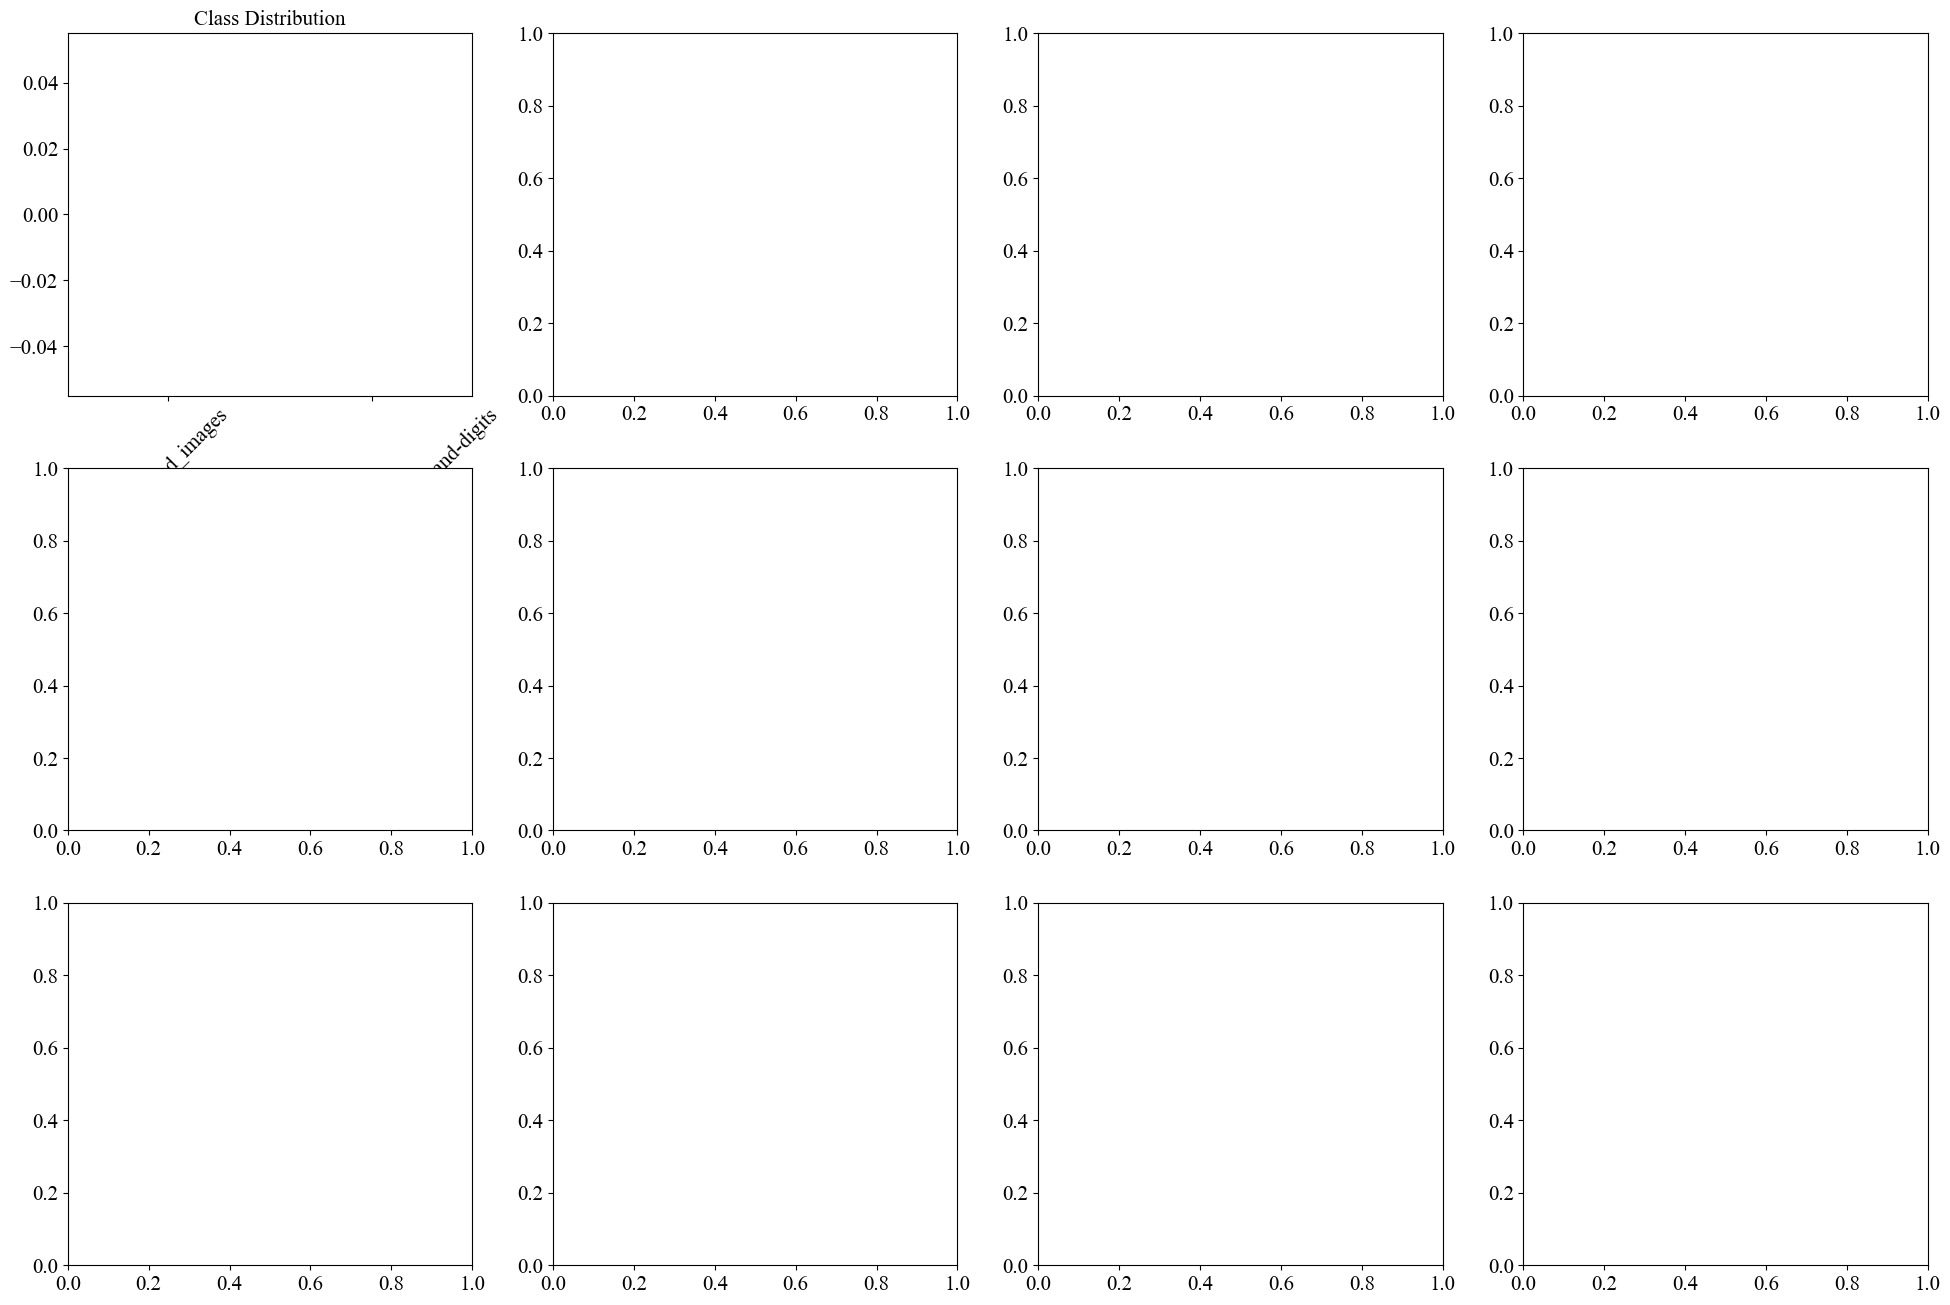

In [9]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from PIL import Image

# ---------- Global plot style ----------
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]
mpl.rcParams["font.size"] = 15
mpl.rcParams["legend.fontsize"] = 15
mpl.rcParams["axes.labelsize"] = 15
mpl.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 15

IMG_EXT = (".png", ".jpg", ".jpeg", ".bmp")


def describe_image_dataset(root_dir):
    """Prints a short text summary of the image dataset before plotting."""
    classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    class_files = {c: [f for f in glob.glob(os.path.join(root_dir, c, "*")) if f.lower().endswith(IMG_EXT)]
                   for c in classes}
    total = sum(len(v) for v in class_files.values())
    print(f"Total images: {total}")
    print(f"Classes ({len(classes)}): {[(c, len(v)) for c, v in class_files.items()]}")
    return classes, class_files


def eda_summary_figure_images(root_dir, output_path="eda_summary_images", resize=(64, 64)):
    """One reusable function: 12-subplot image EDA figure, saved as .eps @600 DPI."""
    classes, class_files = describe_image_dataset(root_dir)
    all_files = [f for files in class_files.values() for f in files]

    widths, heights, means, stds = [], [], [], []
    for f in all_files:
        img = Image.open(f).resize(resize)
        arr = np.array(img).astype(np.float32)
        w, h = Image.open(f).size
        widths.append(w); heights.append(h)
        means.append(arr.mean()); stds.append(arr.std())

    fig, ax = plt.subplots(3, 4, figsize=(24, 16))
    ax = ax.flatten()

    # 1. Class distribution
    ax[0].bar(classes, [len(class_files[c]) for c in classes], color="steelblue")
    ax[0].set_title("Class Distribution"); ax[0].tick_params(axis="x", rotation=45)

    # 2-4. Sample image from first 3 classes
    for i, c in enumerate(classes[:3]):
        img = Image.open(class_files[c][0])
        ax[1 + i].imshow(img, cmap="gray" if img.mode == "L" else None)
        ax[1 + i].set_title(f"Sample: {c}"); ax[1 + i].axis("off")

    # 5. Width distribution
    ax[4].hist(widths, bins=20, color="mediumseagreen")
    ax[4].set_title("Image Width Distribution")

    # 6. Height distribution
    ax[5].hist(heights, bins=20, color="salmon")
    ax[5].set_title("Image Height Distribution")

    # 7. Aspect ratio scatter
    ax[6].scatter(widths, heights, alpha=0.4, s=10)
    ax[6].set_title("Width vs Height")

    # 8. Pixel intensity histogram (sampled)
    sample = np.array([np.array(Image.open(f).resize(resize)) for f in all_files[:100]])
    ax[7].hist(sample.flatten(), bins=50, color="purple")
    ax[7].set_title("Pixel Intensity Distribution")

    # 9. Per-image mean brightness distribution
    ax[8].hist(means, bins=20, color="orange")
    ax[8].set_title("Per-Image Mean Brightness")

    # 10. Per-image std (contrast) distribution
    ax[9].hist(stds, bins=20, color="teal")
    ax[9].set_title("Per-Image Pixel Std Dev")

    # 11. Class imbalance ratio bar (count per class, sorted)
    counts = sorted([len(class_files[c]) for c in classes], reverse=True)
    ax[10].bar(range(len(counts)), counts, color="crimson")
    ax[10].set_title("Sorted Class Counts")

    # 12. Mean image (average across sample) as a heatmap
    mean_img = sample.mean(axis=0)
    ax[11].imshow(mean_img.astype(np.uint8), cmap="gray" if mean_img.ndim == 2 else None)
    ax[11].set_title("Mean Image (sampled)"); ax[11].axis("off")

    plt.tight_layout()
    fig.savefig(f"{output_path}.eps", format="eps", dpi=600)
    plt.show()
    print(f"Saved: {output_path}.eps")


if __name__ == "__main__":
    DATASET_ROOT = r"C:\Users\SSN\Downloads\archive(5)"  # folder containing one subfolder per class

    eda_summary_figure_images(DATASET_ROOT)

In [11]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)


# ---------- 4.2 Regression: train + evaluate all models ----------
def run_regression_models(X_train, X_test, y_train, y_test):
    models = {
        "Linear Regression": LinearRegression(),
        "Ridge": Ridge(),
        "Lasso": Lasso(),
        "Decision Tree": DecisionTreeRegressor(),
        "Random Forest": RandomForestRegressor(),
        "SVR": SVR(),
        "KNN": KNeighborsRegressor(),
    }
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = compute_regression_metrics(y_test, y_pred)
        results[name] = {"model": model, "y_pred": y_pred, "metrics": metrics}
        print(f"{name}: R2={metrics['R2']:.4f}  RMSE={metrics['RMSE']:.4f}")
    return results


# ---------- 4.3 Classification: train + evaluate all models ----------
def run_classification_models(X_train, X_test, y_train, y_test):
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(),
        "SVM": SVC(),
        "KNN": KNeighborsClassifier(),
        "Naive Bayes": GaussianNB(),
    }
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = compute_classification_metrics(y_test, y_pred)
        results[name] = {"model": model, "y_pred": y_pred, "metrics": metrics}
        print(f"{name}: Accuracy={metrics['Accuracy']:.4f}  F1={metrics['F1']:.4f}")
    return results


# ---------- 4.4 Regression performance metrics ----------
def compute_regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    metrics = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}
    print(metrics)
    return metrics


# ---------- 4.5 Classification performance metrics ----------
def compute_classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    metrics = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "Confusion_Matrix": cm}
    print(metrics)
    return metrics


if __name__ == "__main__":
    from sklearn.datasets import load_iris, load_diabetes
    from sklearn.model_selection import train_test_split

    # classification smoke test
    X, y = load_iris(return_X_y=True)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
    run_classification_models(Xtr, Xte, ytr, yte)

    # regression smoke test
    X, y = load_diabetes(return_X_y=True)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
    run_regression_models(Xtr, Xte, ytr, yte)

{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Confusion_Matrix': array([[15,  0,  0],
       [ 0, 11,  0],
       [ 0,  0, 12]], dtype=int64)}
Logistic Regression: Accuracy=1.0000  F1=1.0000
{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Confusion_Matrix': array([[15,  0,  0],
       [ 0, 11,  0],
       [ 0,  0, 12]], dtype=int64)}
Decision Tree: Accuracy=1.0000  F1=1.0000
{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Confusion_Matrix': array([[15,  0,  0],
       [ 0, 11,  0],
       [ 0,  0, 12]], dtype=int64)}
Random Forest: Accuracy=1.0000  F1=1.0000
{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Confusion_Matrix': array([[15,  0,  0],
       [ 0, 11,  0],
       [ 0,  0, 12]], dtype=int64)}
SVM: Accuracy=1.0000  F1=1.0000
{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0, 'Confusion_Matrix': array([[15,  0,  0],
       [ 0, 11,  0],
       [ 0,  0, 12]], dtype=int64)}
KNN: Accuracy=1.0000  F1=1.0000
{'Ac